In [1]:
import numpy as np
import pynumdiff

from pynumdiff.utils.utility import wrap_angle
from pynumdiff.utils import simulate, evaluate

/Users/florisvb/src/PyNumDiff/pynumdiff/__init__.py:9: UserWarning: tvrdiff, robustdiff, and lineardiff not available due to lack of convex solver. To use those, install CVXPY.
  warn("tvrdiff, robustdiff, and lineardiff not available due to lack of convex solver. To use those, install CVXPY.")


# Generate testing data

Here we amplify the usual signal to get outside the -pi to pi bound.

In [2]:
noise_type = 'normal' # noise is generated using np.random, e.g. 'normal', 'uniform', 'poisson'
noise_parameters = [0, 0.5]  # compatible with np.random functions 
random_seed = 1

dt = 0.01 # step size and series length in terms of independent variable
duration = 4

x, x_truth, dxdt_truth = simulate.lorenz_x(duration=duration, dt=dt, outliers=False,
                                           noise_type=noise_type, noise_parameters=noise_parameters)

# amplify signal
gain = 4
x_truth *= gain
dxdt_truth *= gain

# add noise
x = simulate._add_noise(x_truth, random_seed, noise_type, noise_parameters)

# wrap
x = wrap_angle(x)
x_truth = wrap_angle(x_truth)

# Naive numerical differentiation (without considering wrapping)

(<Figure size 1800x600 with 2 Axes>,
 array([<Axes: xlabel='Time', ylabel='Position'>,
        <Axes: xlabel='Time', ylabel='Velocity'>], dtype=object))

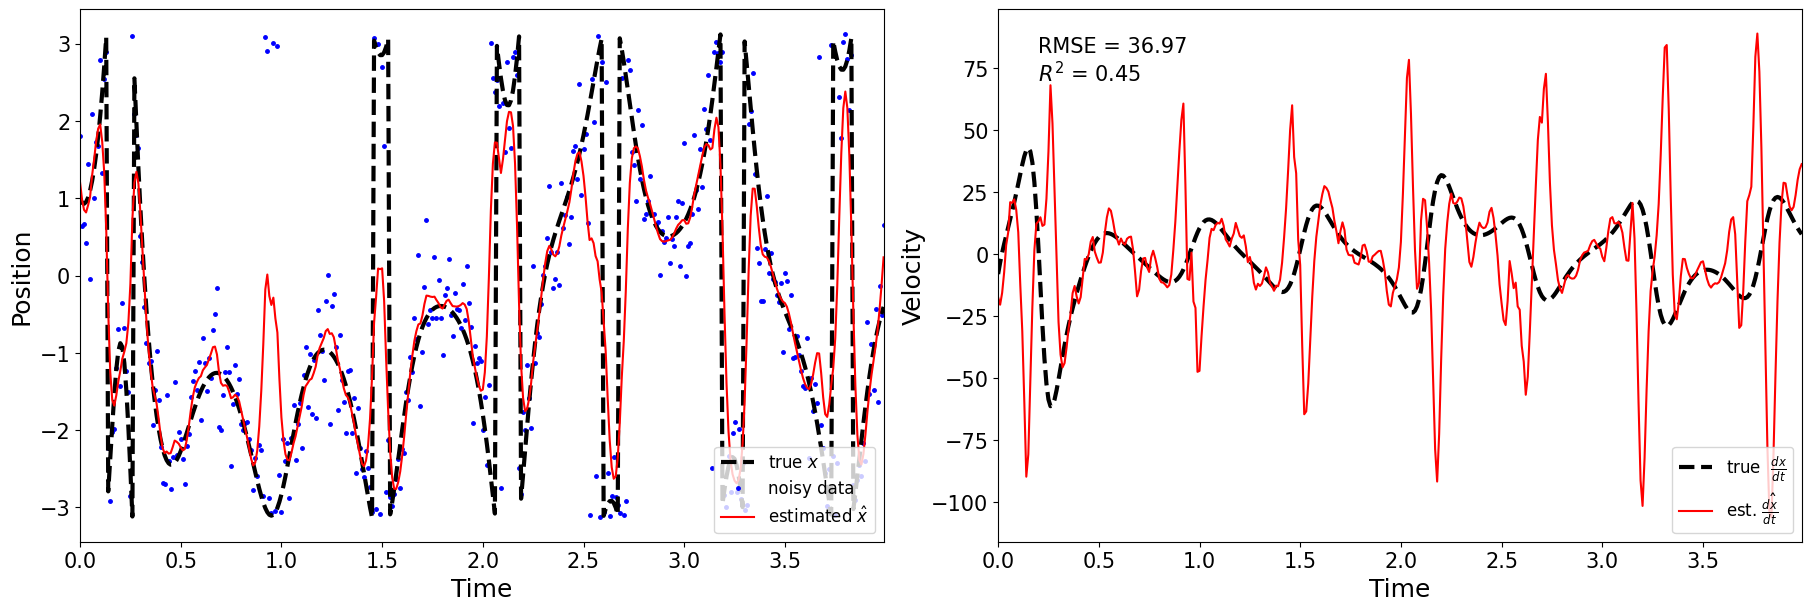

In [3]:
x_hat, dxdt_hat = pynumdiff.kalman_smooth.rtsdiff(x, dt, 1, 5, True, axis=0, circular_vars=False)
x_hat_wrapped = wrap_angle(x_hat)

evaluate.plot(x, dt, x_hat_wrapped, dxdt_hat, x_truth, dxdt_truth)

# Now with circular_vars flag

(<Figure size 1800x600 with 2 Axes>,
 array([<Axes: xlabel='Time', ylabel='Position'>,
        <Axes: xlabel='Time', ylabel='Velocity'>], dtype=object))

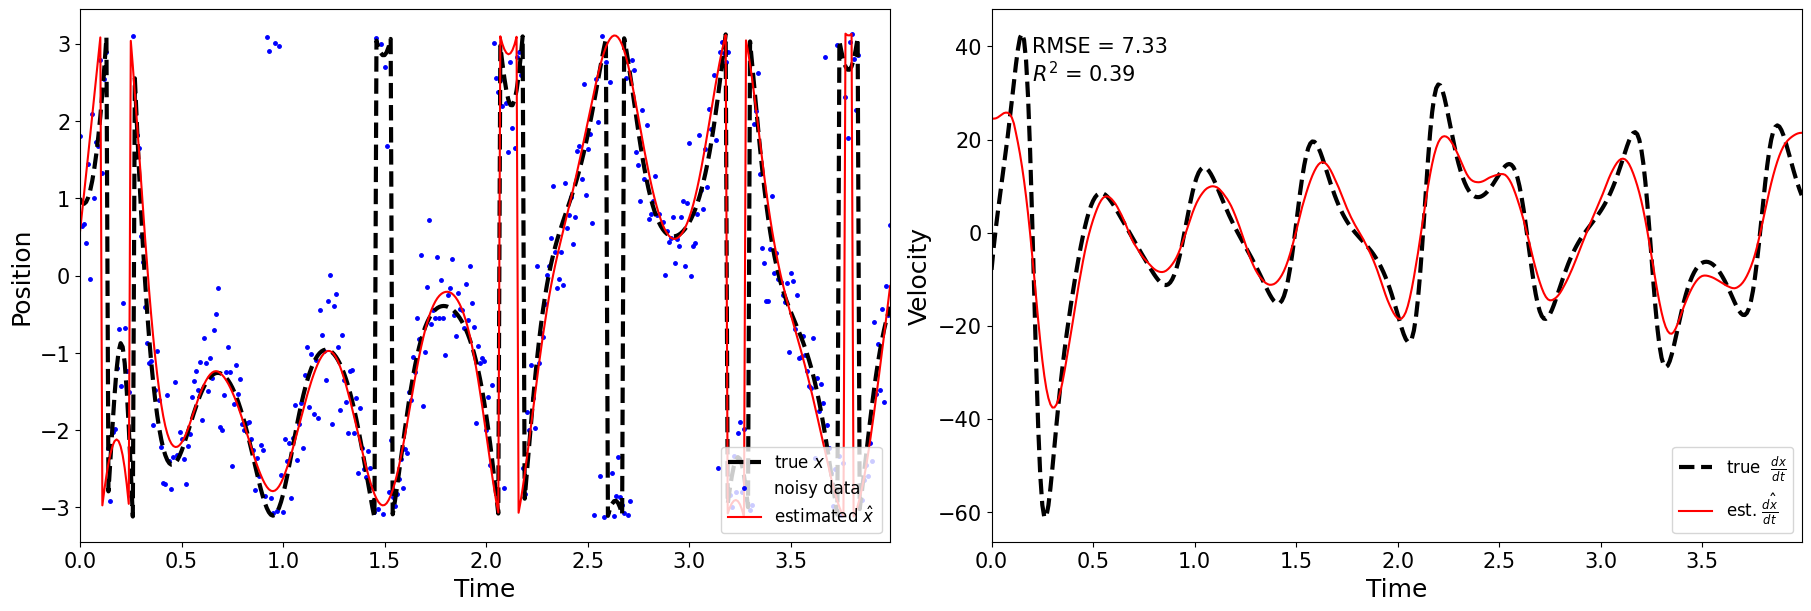

In [4]:
x_hat, dxdt_hat = pynumdiff.kalman_smooth.rtsdiff(x, dt, 1, 3, True, axis=0, circular_vars=True)
x_hat_wrapped = wrap_angle(x_hat)

evaluate.plot(x, dt, x_hat_wrapped, dxdt_hat, x_truth, dxdt_truth)

# Test degrees

In [5]:
x *= 180/np.pi
x_truth *= 180/np.pi
dxdt_truth *= 180/np.pi

(<Figure size 1800x600 with 2 Axes>,
 array([<Axes: xlabel='Time', ylabel='Position'>,
        <Axes: xlabel='Time', ylabel='Velocity'>], dtype=object))

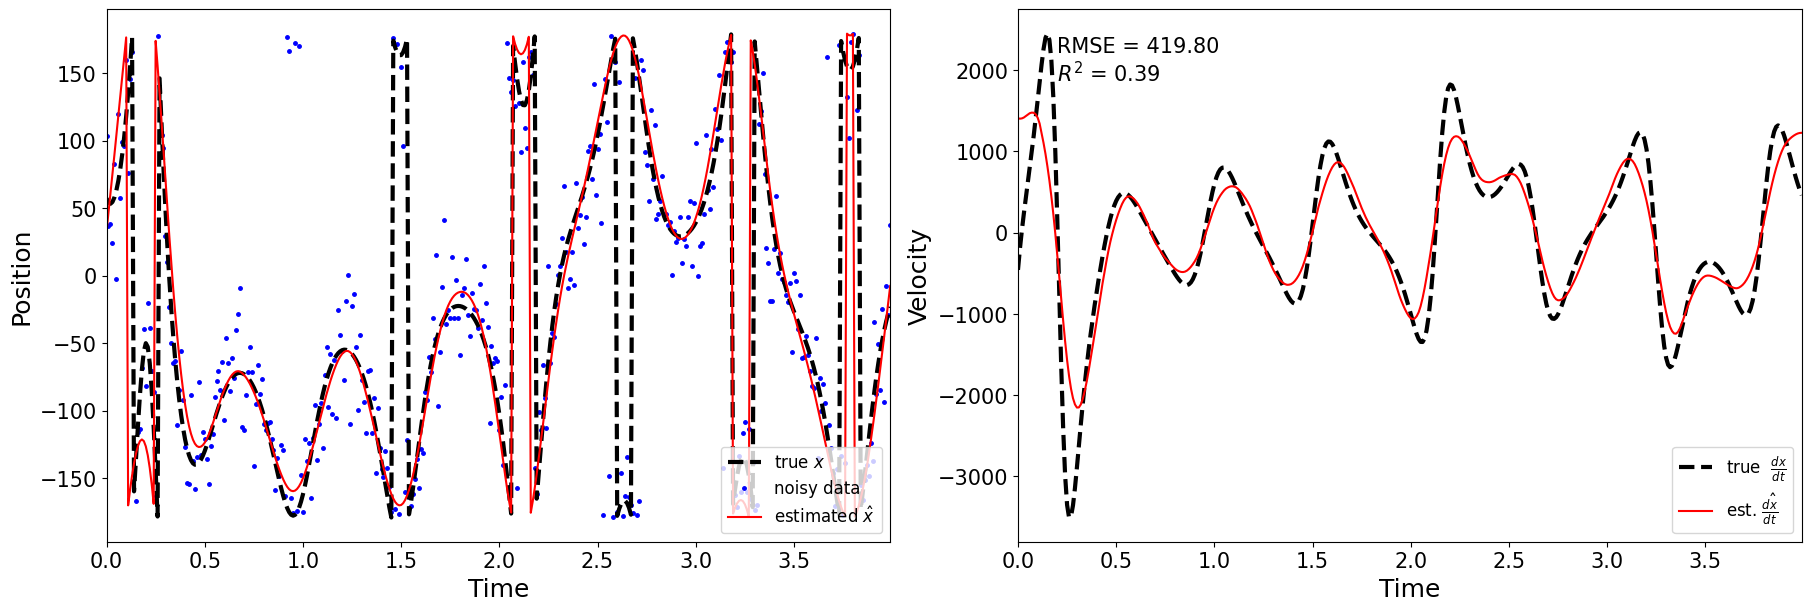

In [6]:
x_hat, dxdt_hat = pynumdiff.kalman_smooth.rtsdiff(x, dt, 1, 3, True, axis=0, circular_vars=True, circular_units='deg')
x_hat_wrapped = wrap_angle(x_hat, units='deg')

evaluate.plot(x, dt, x_hat_wrapped, dxdt_hat, x_truth, dxdt_truth)

# Test multidimensional

In [7]:
v, v_truth, dvdt_truth = simulate.triangle(duration=duration, dt=dt, outliers=False,
                                           noise_type=noise_type, noise_parameters=noise_parameters)

In [8]:
X = np.vstack((x, v)).T
print('Shape: ')
print(X.shape)

Shape: 
(400, 2)


(<Figure size 1800x600 with 2 Axes>,
 array([<Axes: xlabel='Time', ylabel='Position'>,
        <Axes: xlabel='Time', ylabel='Velocity'>], dtype=object))

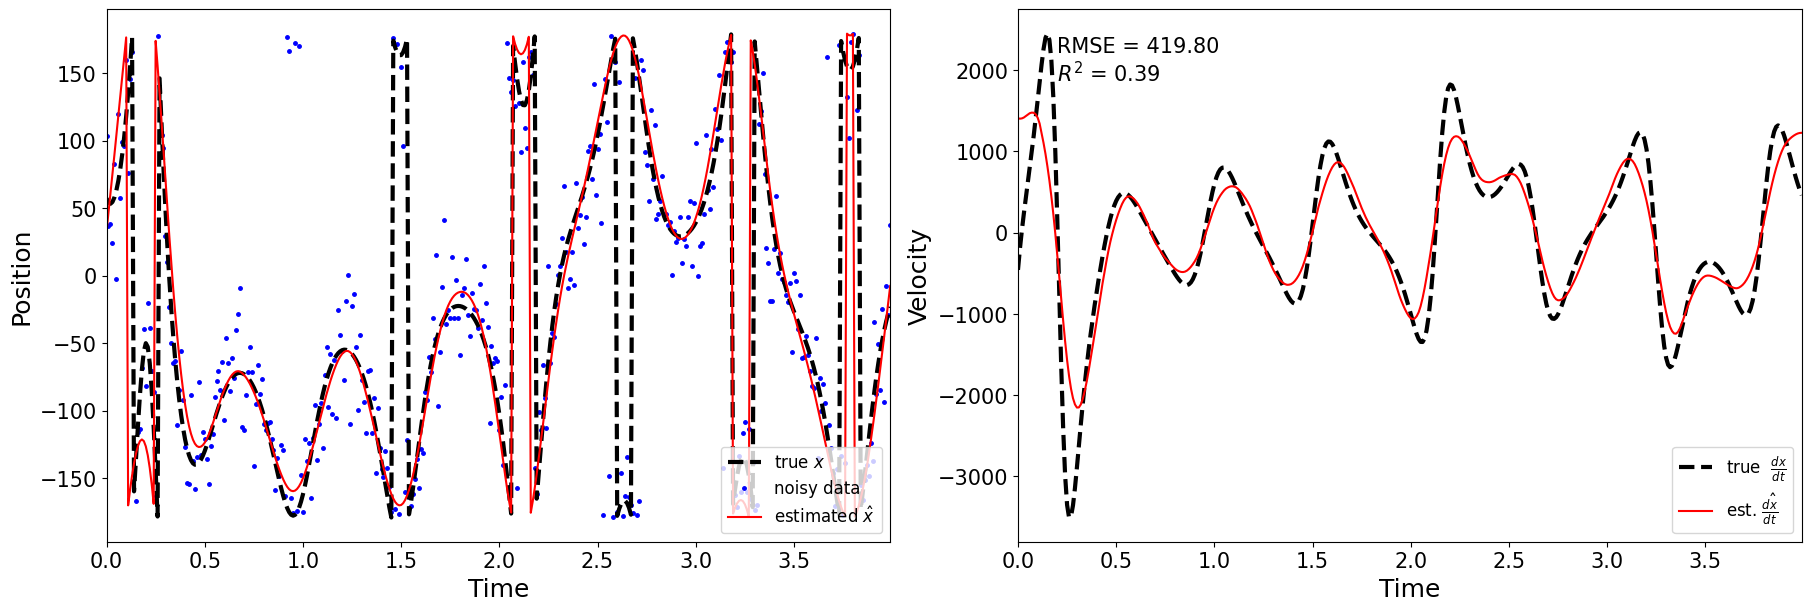

In [9]:
X_hat, dXdt_hat = pynumdiff.kalman_smooth.rtsdiff(X, dt, 1, 3, True, axis=0, circular_vars=[True, False], circular_units='deg')
x_hat_wrapped = wrap_angle(X_hat[:,0], units='deg')

evaluate.plot(x, dt, x_hat_wrapped, dXdt_hat[:,0], x_truth, dxdt_truth)

# Test wrapping from 0 to 360

In [10]:
x += 180
x_truth += 180

(<Figure size 1800x600 with 2 Axes>,
 array([<Axes: xlabel='Time', ylabel='Position'>,
        <Axes: xlabel='Time', ylabel='Velocity'>], dtype=object))

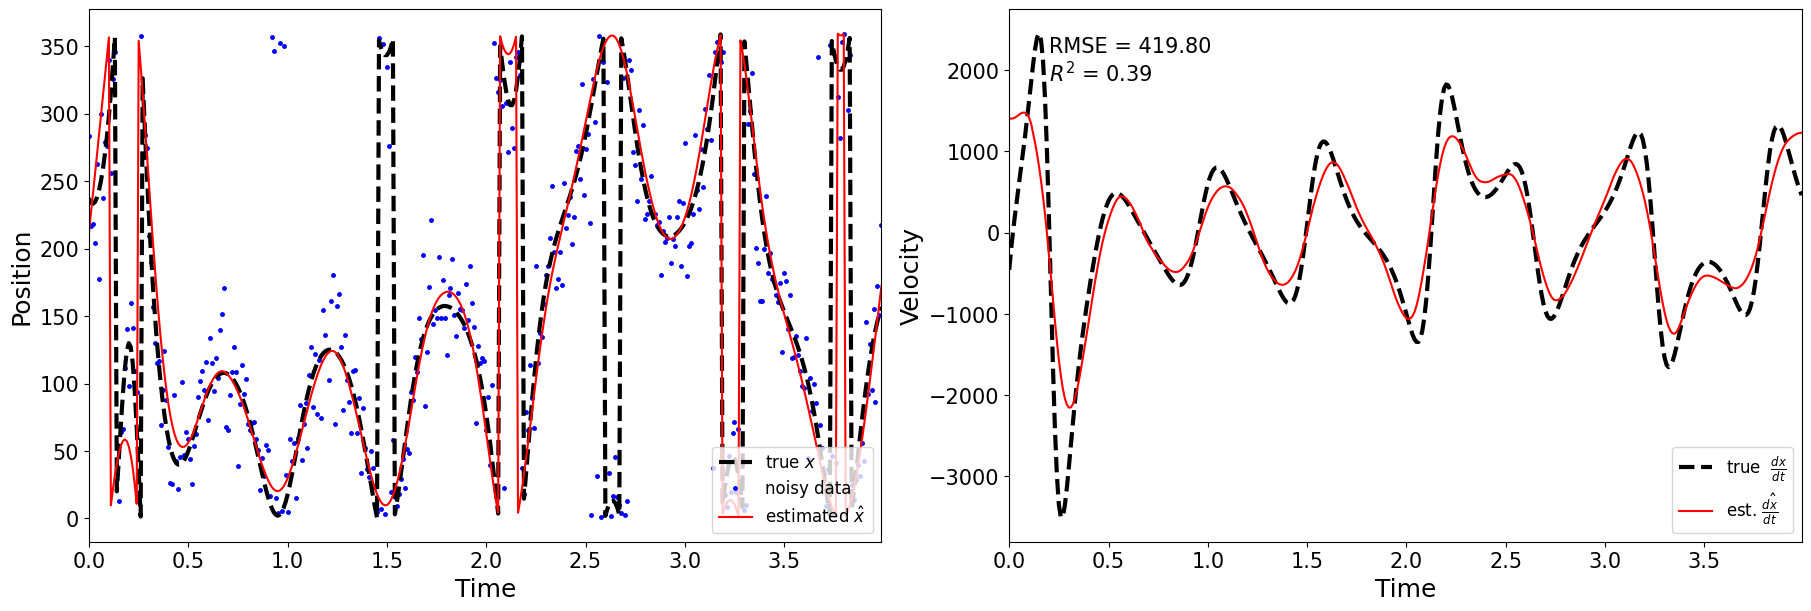

In [12]:
x_hat, dxdt_hat = pynumdiff.kalman_smooth.rtsdiff(x, dt, 1, 3, True, axis=0, 
                                                  circular_vars=True, circular_units='deg')

x_hat_wrapped = wrap_angle(x_hat, units='deg', range='positive')

evaluate.plot(x, dt, x_hat_wrapped, dxdt_hat, x_truth, dxdt_truth)